GERMAN CREDIT RISK DATASET

Dataset Shape:
(1000, 21)

First 5 Rows:
  Status_Checking  Duration Credit_History Purpose  Credit_Amount Savings  \
0             A11         6            A34     A43           1169     A65   
1             A12        48            A32     A43           5951     A61   
2             A14        12            A34     A46           2096     A61   
3             A11        42            A32     A42           7882     A61   
4             A11        24            A33     A40           4870     A61   

  Employment  Installment_Rate Personal_Status_Sex Other_Debtors  ...  \
0        A75                 4                 A93          A101  ...   
1        A73                 2                 A92          A101  ...   
2        A74                 2                 A93          A101  ...   
3        A74                 2                 A93          A103  ...   
4        A73                 3                 A93          A101  ...   

   Property Age  Other_Instal

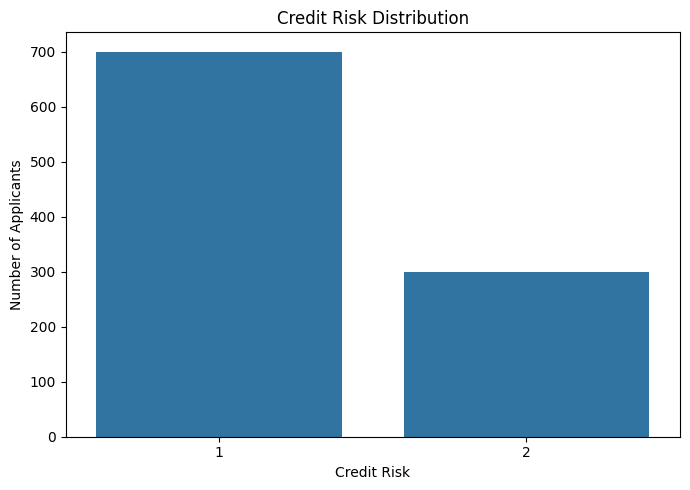


NUMERICAL VARIABLES
['Duration', 'Credit_Amount', 'Installment_Rate', 'Residence_Since', 'Age', 'Existing_Credits', 'Liable_People']

CATEGORICAL VARIABLES
['Status_Checking', 'Credit_History', 'Purpose', 'Savings', 'Employment', 'Personal_Status_Sex', 'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing', 'Job', 'Telephone', 'Foreign_Worker']

DESCRIPTIVE STATISTICS
          Duration  Credit_Amount  Installment_Rate  Residence_Since  \
count  1000.000000    1000.000000       1000.000000      1000.000000   
mean     20.903000    3271.258000          2.973000         2.845000   
std      12.058814    2822.736876          1.118715         1.103718   
min       4.000000     250.000000          1.000000         1.000000   
25%      12.000000    1365.500000          2.000000         2.000000   
50%      18.000000    2319.500000          3.000000         3.000000   
75%      24.000000    3972.250000          4.000000         4.000000   
max      72.000000   18424.000000        

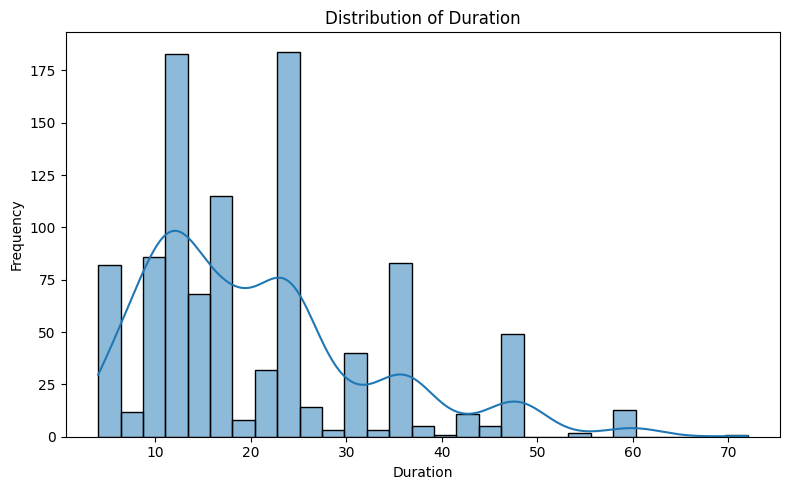

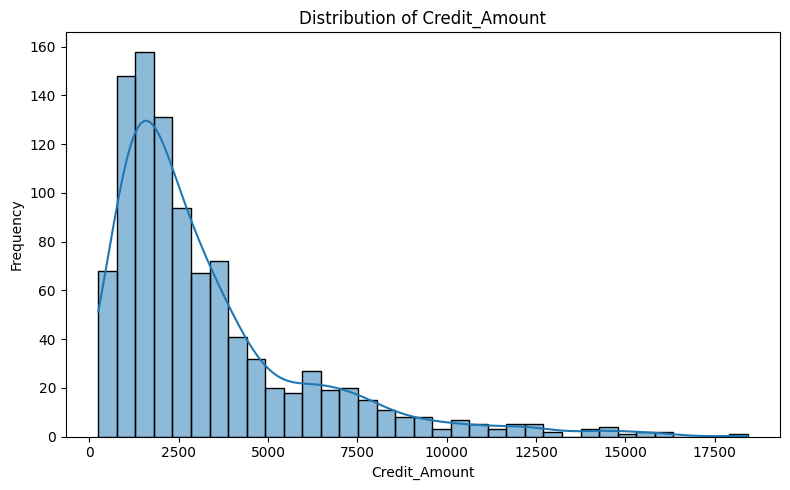

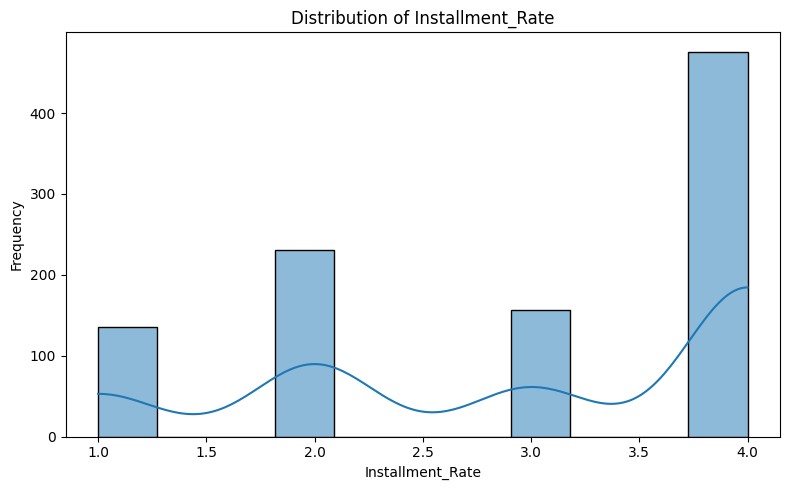

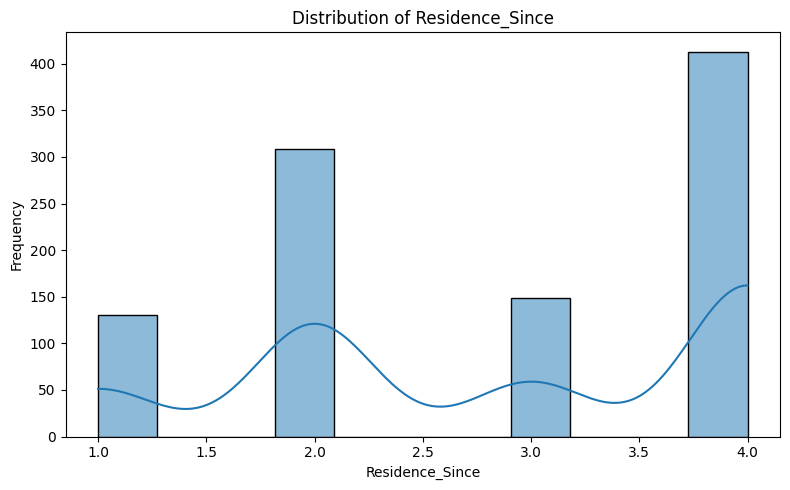

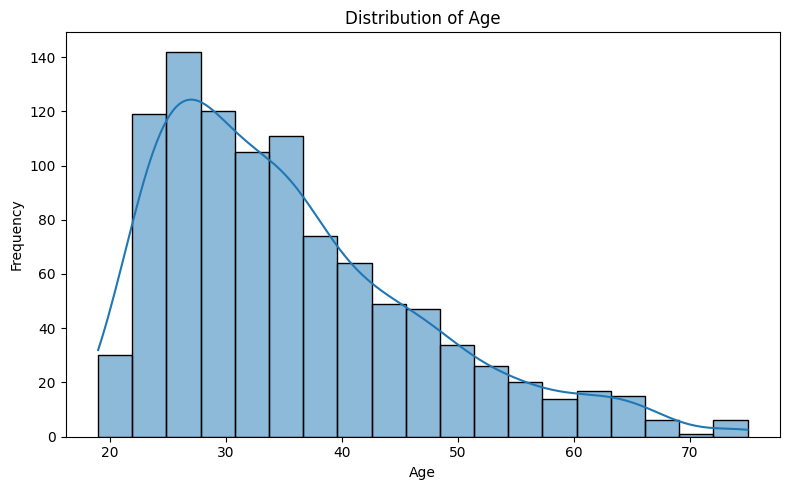

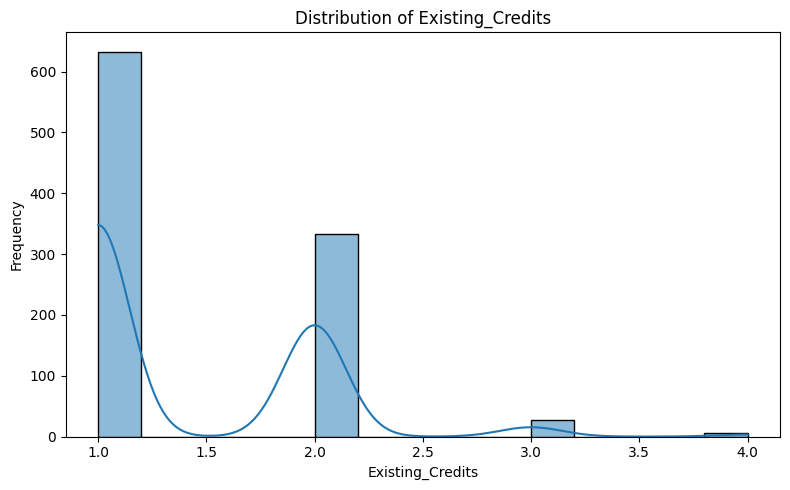

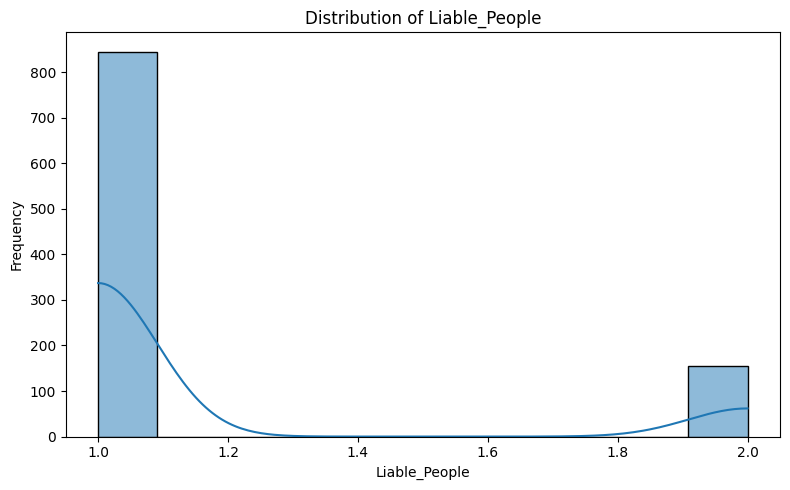

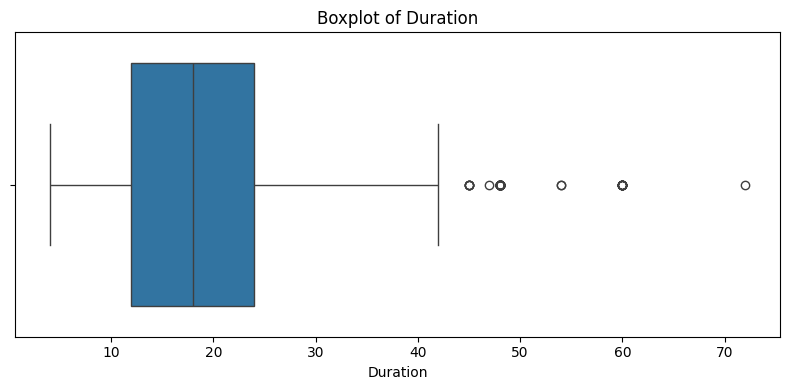

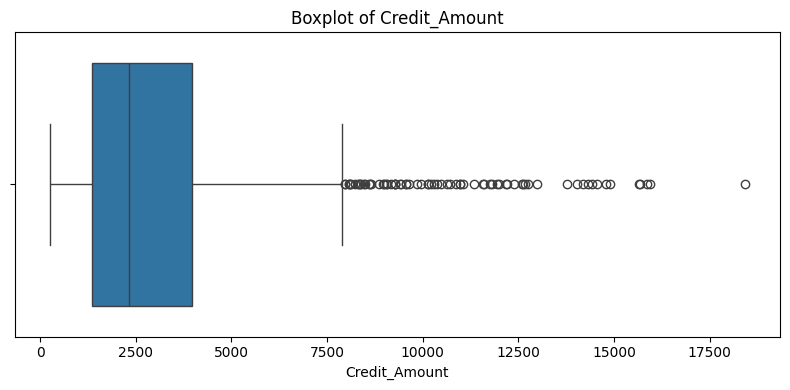

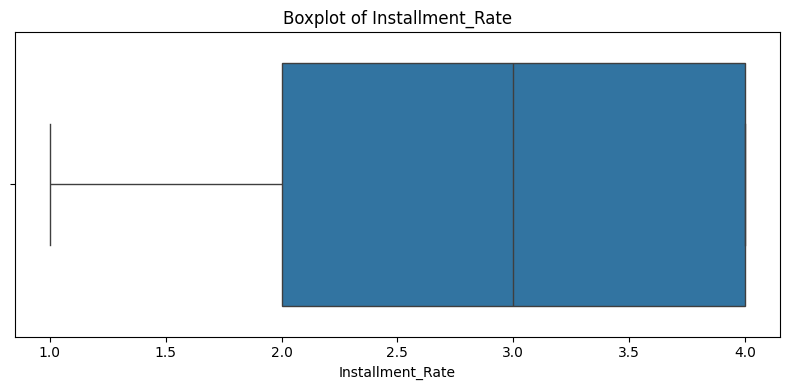

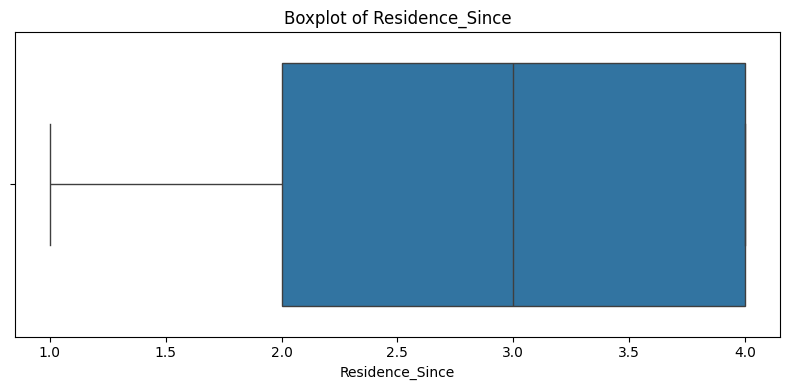

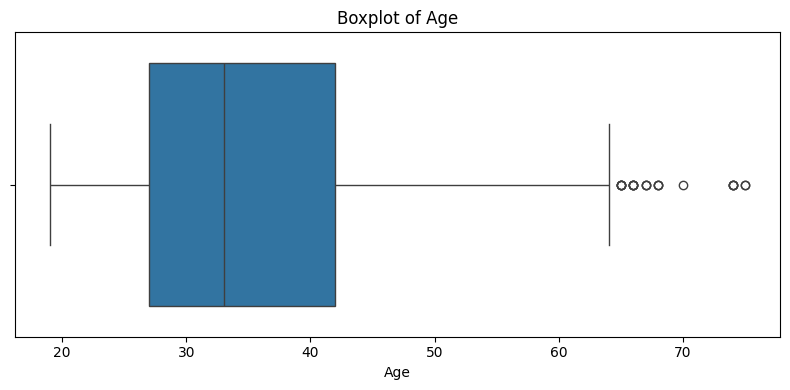

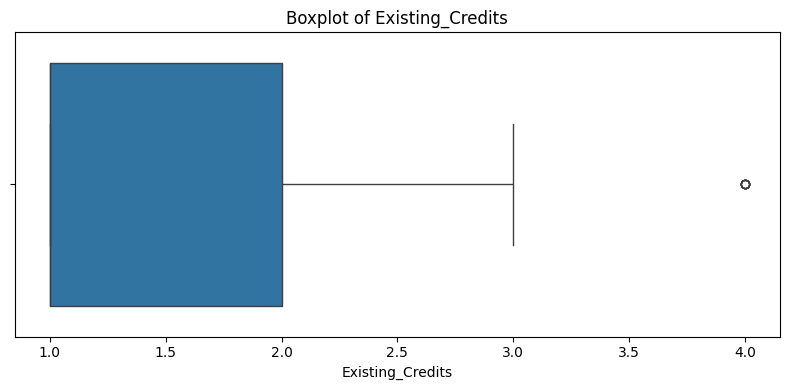

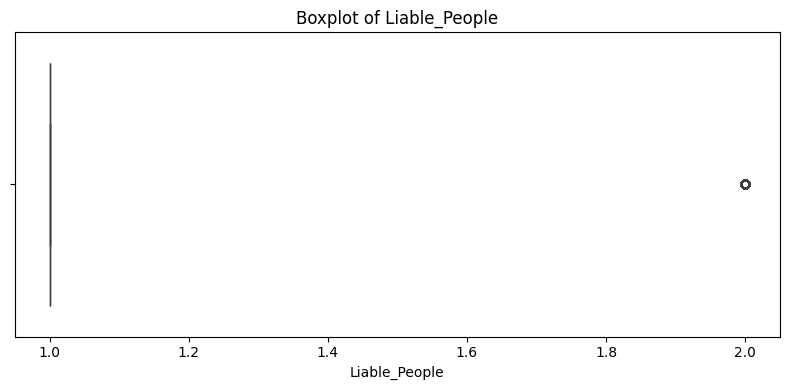

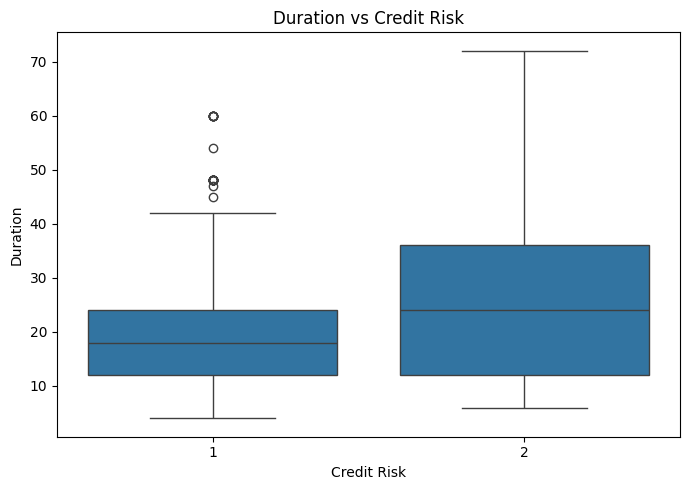

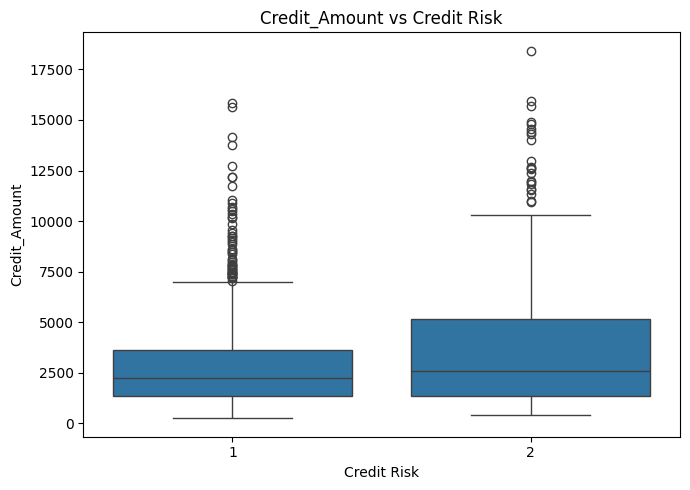

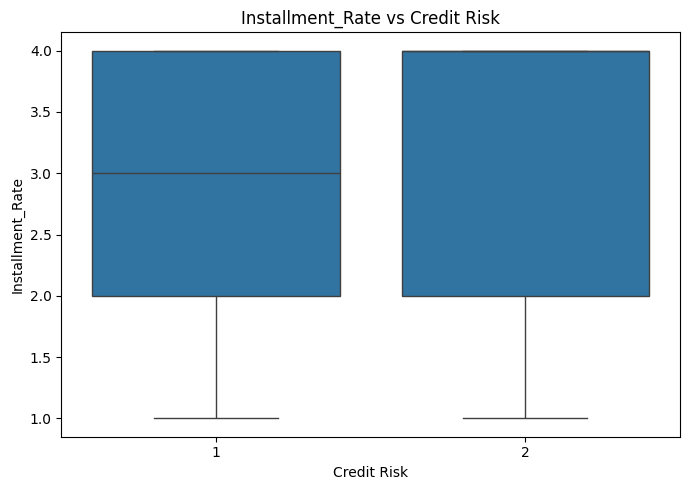

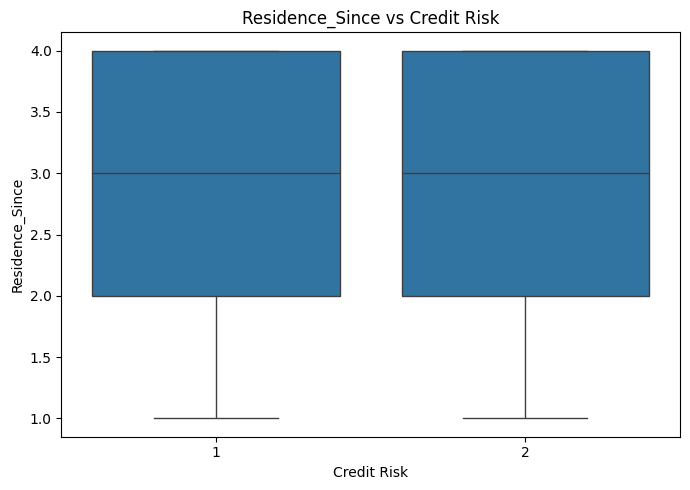

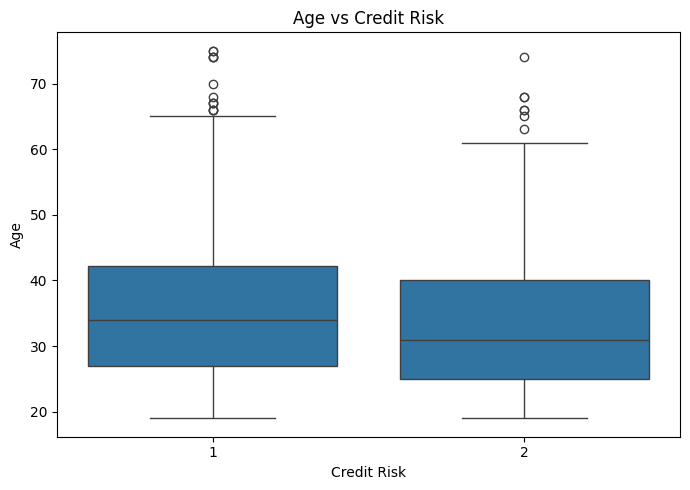

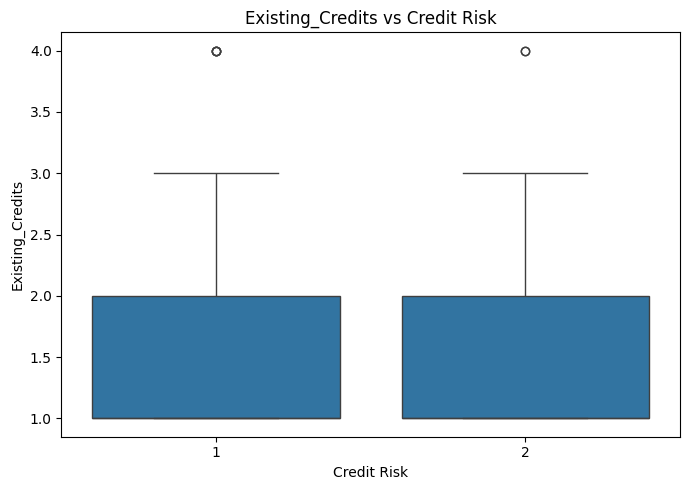

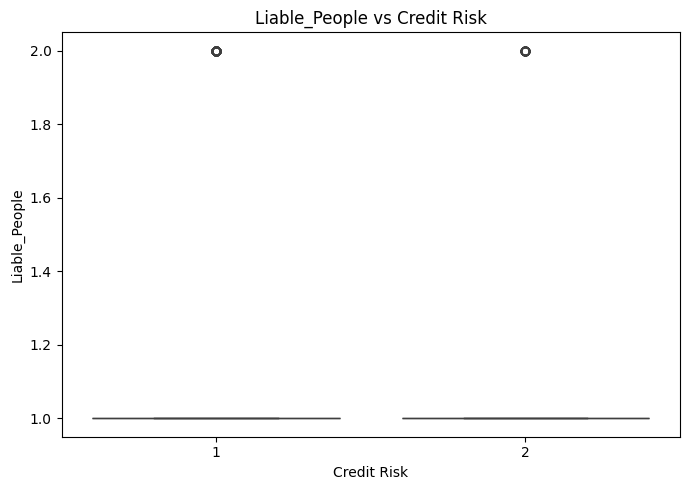

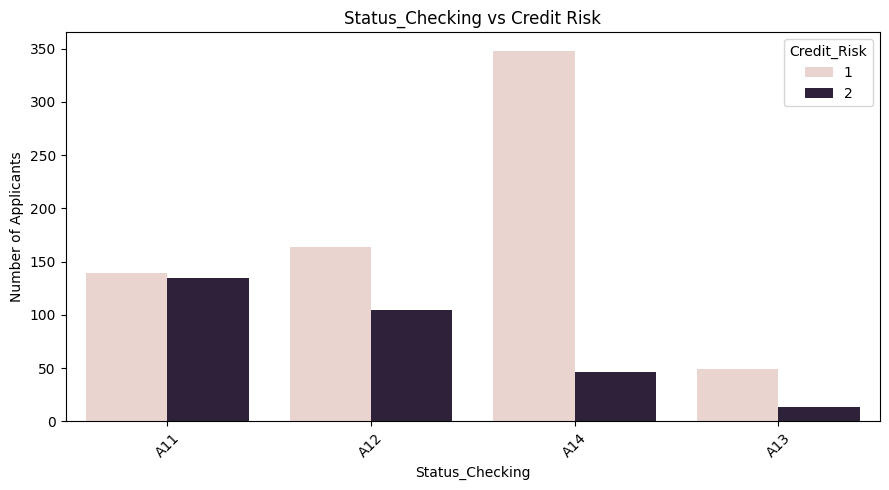

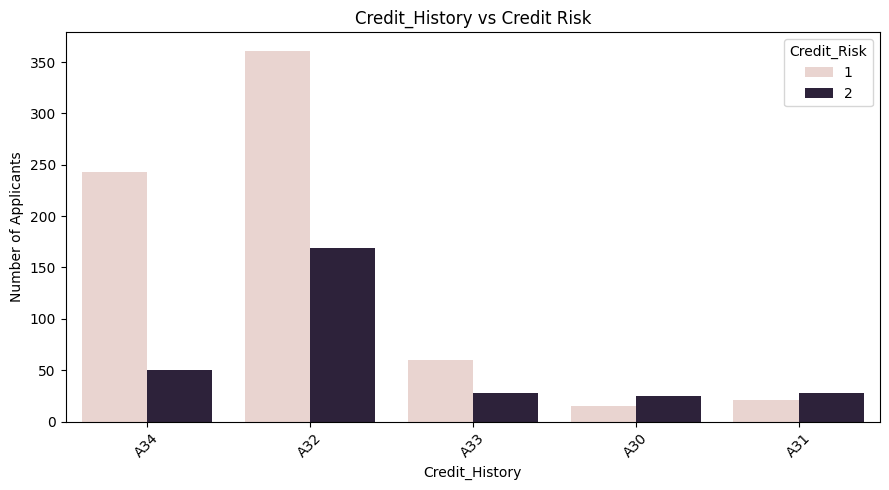

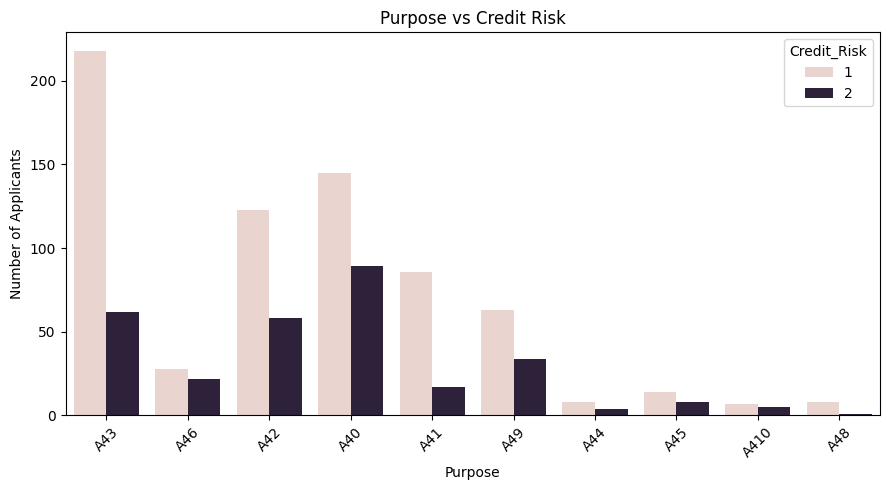

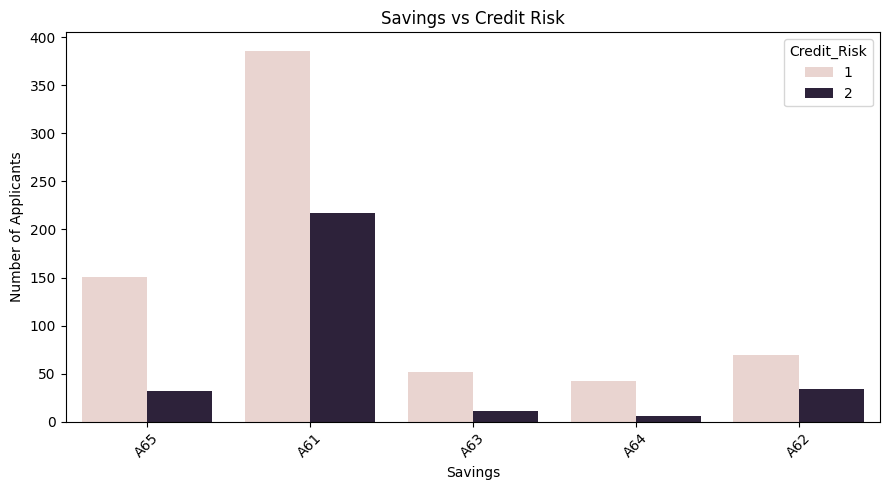

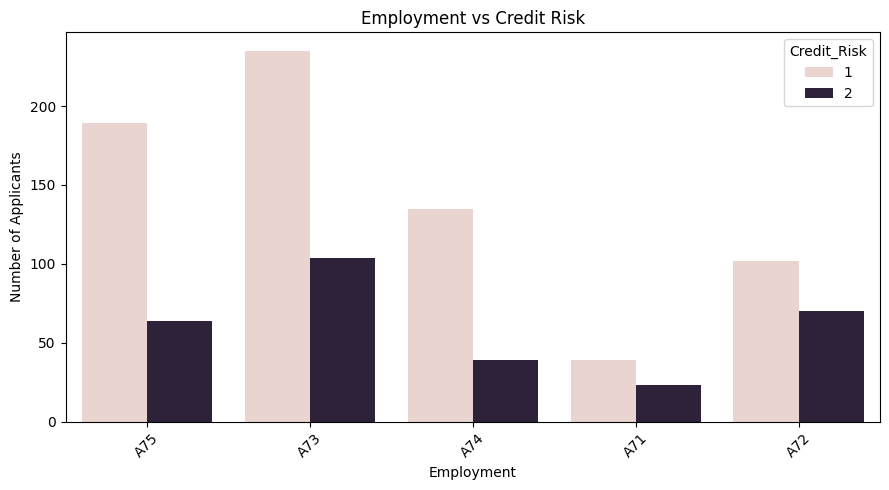

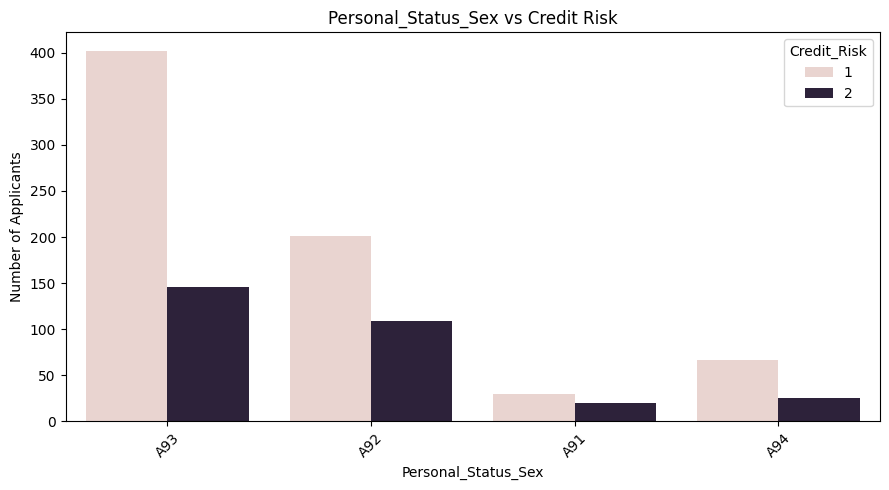

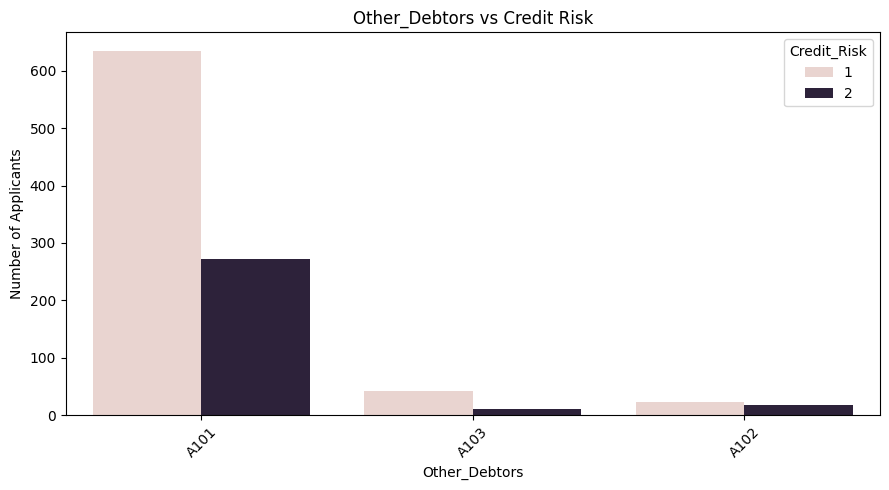

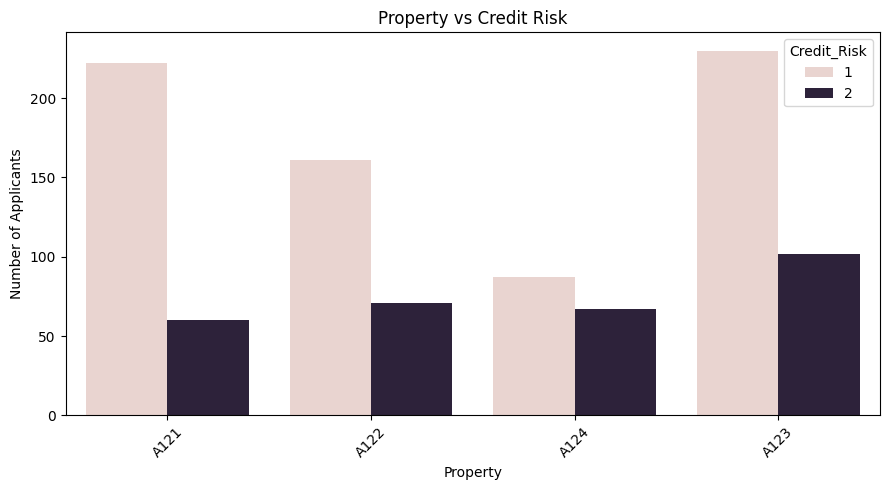

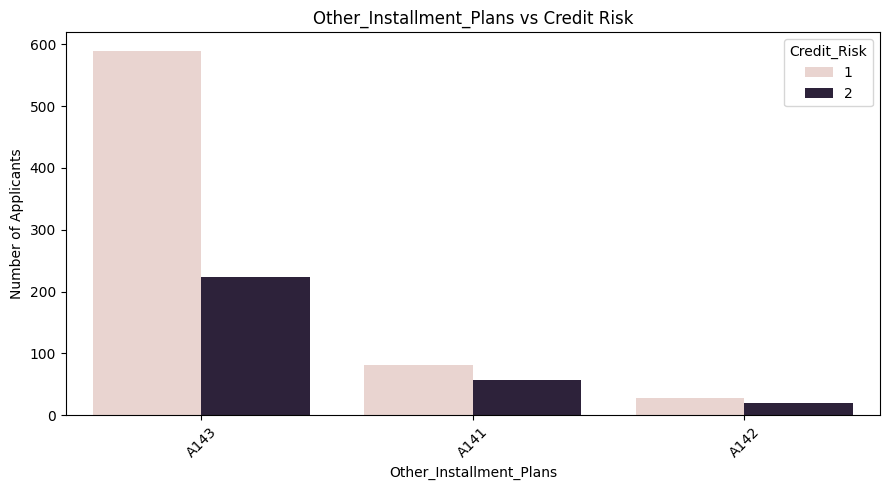

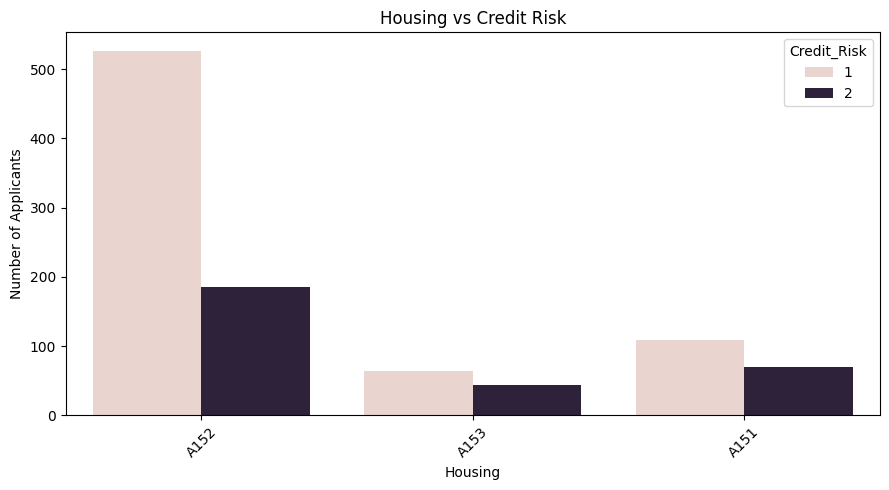

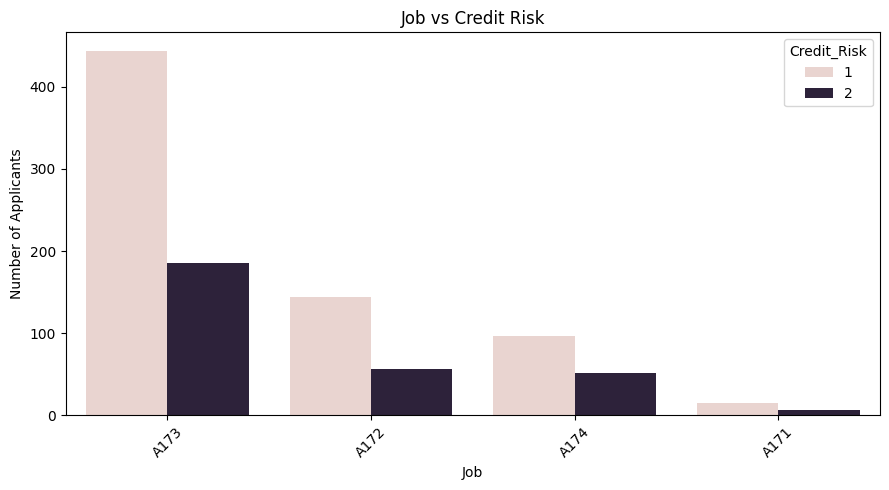

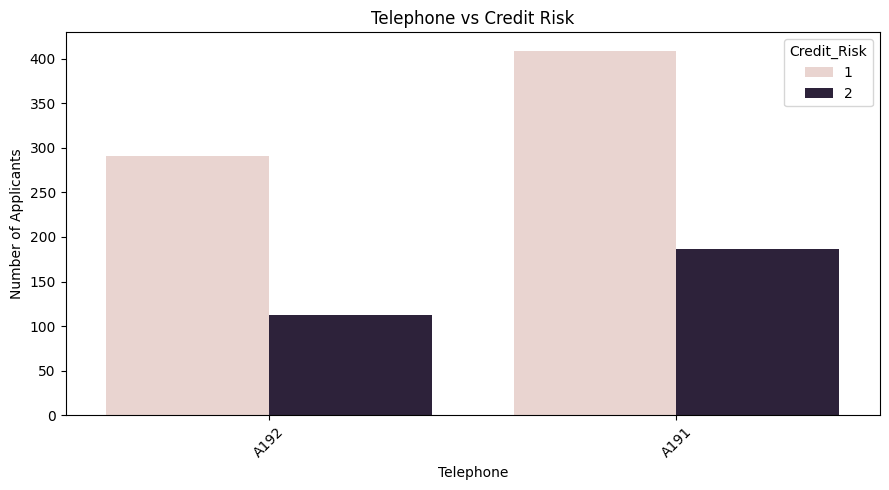

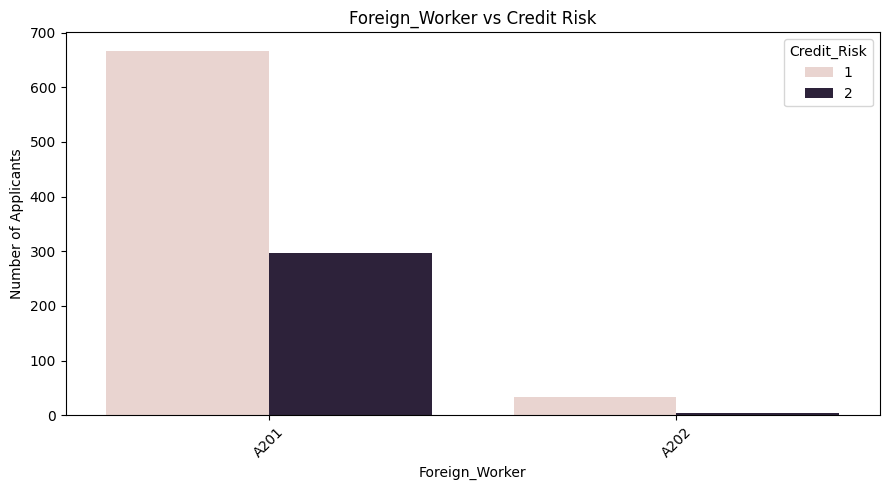


CORRELATION MATRIX
                  Duration  Credit_Amount  Installment_Rate  Residence_Since  \
Duration          1.000000       0.624984          0.074749         0.034067   
Credit_Amount     0.624984       1.000000         -0.271316         0.028926   
Installment_Rate  0.074749      -0.271316          1.000000         0.049302   
Residence_Since   0.034067       0.028926          0.049302         1.000000   
Age              -0.036136       0.032716          0.058266         0.266419   
Existing_Credits -0.011284       0.020795          0.021669         0.089625   
Liable_People    -0.023834       0.017142         -0.071207         0.042643   
Credit_Risk       0.214927       0.154739          0.072404         0.002967   

                       Age  Existing_Credits  Liable_People  Credit_Risk  
Duration         -0.036136         -0.011284      -0.023834     0.214927  
Credit_Amount     0.032716          0.020795       0.017142     0.154739  
Installment_Rate  0.058266        

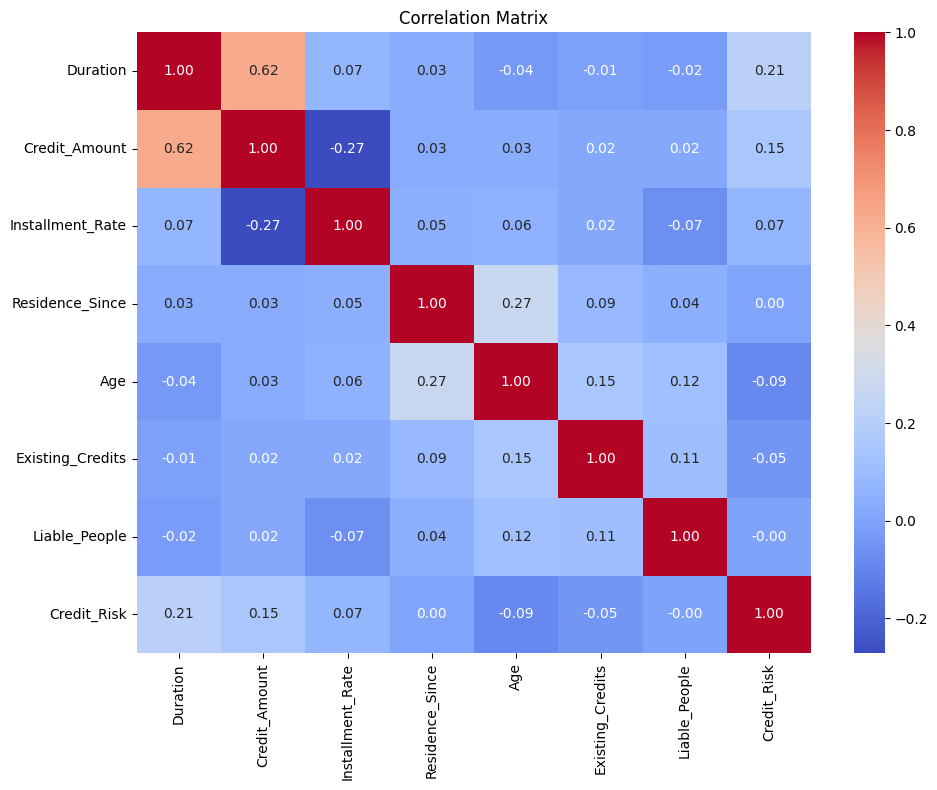


EDA COMPLETED
Dataset Shape: (1000, 21)
Missing Values: 0
Duplicate Rows: 0
EDA plots saved in: outputs/figures/


In [1]:
# ============================================================
# CREDIT RISK PREDICTION
# File: data_eda.py
# Purpose: Data Loading and Exploratory Data Analysis
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/statlog/german/german.data"
)

COLUMN_NAMES = [
    "Status_Checking", "Duration", "Credit_History", "Purpose", "Credit_Amount",
    "Savings", "Employment", "Installment_Rate", "Personal_Status_Sex",
    "Other_Debtors", "Residence_Since", "Property", "Age",
    "Other_Installment_Plans", "Housing", "Existing_Credits", "Job",
    "Liable_People", "Telephone", "Foreign_Worker", "Credit_Risk"
]

# 1. Function to safely load data elsewhere
def load_data():
    df = pd.read_csv(DATA_URL, sep=r"\s+", header=None)
    df.columns = COLUMN_NAMES
    return df

# 2. Code that ONLY runs when executing data_eda.py directly
if __name__ == "__main__":
    os.makedirs("outputs/figures", exist_ok=True)
    df = load_data()

    # Put all print statements, distribution plots, boxplots,
    # correlation heatmap, and figure saves down here...

# ============================================================
# 3. CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    "outputs/figures",
    exist_ok=True
)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_URL,
    sep=r"\s+",
    header=None
)

df.columns = COLUMN_NAMES


print("=" * 60)
print("GERMAN CREDIT RISK DATASET")
print("=" * 60)


# ============================================================
# 5. BASIC DATASET INFORMATION
# ============================================================

print("\nDataset Shape:")
print(df.shape)


print("\nFirst 5 Rows:")
print(df.head())


print("\nLast 5 Rows:")
print(df.tail())


print("\nData Types:")
print(df.dtypes)


# ============================================================
# 6. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)


print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


# ============================================================
# 7. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)


# ============================================================
# 8. TARGET VARIABLE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("TARGET VARIABLE")
print("=" * 60)

print(
    df["Credit_Risk"].value_counts()
)


print("\nTarget Percentage:")

target_percentage = (
    df["Credit_Risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentage)


# ------------------------------------------------------------
# Target distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_Risk"
)

plt.title(
    "Credit Risk Distribution"
)

plt.xlabel(
    "Credit Risk"
)

plt.ylabel(
    "Number of Applicants"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/01_target_distribution.png"
)

plt.show()


# ============================================================
# 9. DEFINE NUMERICAL VARIABLES
# ============================================================

numerical_columns = [
    "Duration",
    "Credit_Amount",
    "Installment_Rate",
    "Residence_Since",
    "Age",
    "Existing_Credits",
    "Liable_People"
]


print("\n" + "=" * 60)
print("NUMERICAL VARIABLES")
print("=" * 60)

print(numerical_columns)


# ============================================================
# 10. DEFINE CATEGORICAL VARIABLES
# ============================================================

categorical_columns = [
    "Status_Checking",
    "Credit_History",
    "Purpose",
    "Savings",
    "Employment",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Property",
    "Other_Installment_Plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign_Worker"
]


print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

print(categorical_columns)


# ============================================================
# 11. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(
    df[numerical_columns].describe()
)


# ============================================================
# 12. NUMERICAL VARIABLE DISTRIBUTIONS
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()

    filename = (
        "outputs/figures/"
        + column.lower()
        + "_distribution.png"
    )

    plt.savefig(filename)

    plt.show()


# ============================================================
# 13. OUTLIER ANALYSIS
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Boxplot of {column}"
    )

    plt.tight_layout()

    filename = (
        "outputs/figures/"
        + column.lower()
        + "_boxplot.png"
    )

    plt.savefig(filename)

    plt.show()


# ============================================================
# 14. NUMERICAL VARIABLES VS CREDIT RISK
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Credit_Risk",
        y=column
    )

    plt.title(
        f"{column} vs Credit Risk"
    )

    plt.xlabel(
        "Credit Risk"
    )

    plt.ylabel(column)

    plt.tight_layout()

    filename = (
        "outputs/figures/"
        + column.lower()
        + "_vs_risk.png"
    )

    plt.savefig(filename)

    plt.show()


# ============================================================
# 15. CATEGORICAL VARIABLES VS CREDIT RISK
# ============================================================

for column in categorical_columns:

    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="Credit_Risk"
    )

    plt.title(
        f"{column} vs Credit Risk"
    )

    plt.xlabel(column)

    plt.ylabel(
        "Number of Applicants"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    filename = (
        "outputs/figures/"
        + column.lower()
        + "_vs_risk.png"
    )

    plt.savefig(filename)

    plt.show()


# ============================================================
# 16. CORRELATION ANALYSIS
# ============================================================

correlation_matrix = (
    df[numerical_columns + ["Credit_Risk"]]
    .corr()
)


print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(correlation_matrix)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/02_correlation_matrix.png"
)

plt.show()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EDA COMPLETED")
print("=" * 60)

print(
    "Dataset Shape:",
    df.shape
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "EDA plots saved in:",
    "outputs/figures/"
)